In [1]:
import numpy as np
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
data = load_diabetes()

In [3]:
X = data.data
y = data.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
m, n_features = X_train.shape
W = np.zeros(n_features)
b = 0.0
print(m)

353


In [6]:
def mse_loss(y_hat, y):
  return np.mean((y_hat-y)**2)

In [7]:
epochs = 5000
learning_rate = 0.1
loss_history = []

for epoch in range(epochs):
  y_hat = X_train @ W + b
  loss = mse_loss(y_hat, y_train)
  loss_history.append(loss)
  error = y_hat - y_train #y-y_hat
  #(n,1)
  dW = (2/m)*X_train.T@error
  db = (2/m)*np.sum(error)

  W = W - learning_rate*dW
  b = b - learning_rate*db

  if (epoch % 500==0):
    print(epoch)
    print(f"Loss: {loss:.2f}")



0
Loss: 29711.32
500
Loss: 4008.15
1000
Loss: 3443.44
1500
Loss: 3214.66
2000
Loss: 3094.02
2500
Loss: 3022.85
3000
Loss: 2979.00
3500
Loss: 2951.39
4000
Loss: 2933.73
4500
Loss: 2922.26


In [8]:
training_predictions = X_train @W + b
mse_loss(training_predictions, y_train)

np.float64(2914.701553373165)

In [9]:
testing_predictions = X_test @W + b
mse_loss(testing_predictions, y_test)

np.float64(2866.882705603096)

In [10]:
#R^2 = 1-(sum of squared errors/variance)

ss_err = np.sum((y_test - testing_predictions)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)

R2 = 1-(ss_err/ss_tot)
print(R2)

0.45889003530225847


In [11]:
def new_predict(example, W, b):
  return example @ W + b
example = X_test[0].reshape(1,-1)
predict = new_predict(example, W, b)
print(predict[0])
print(y_test[0])

142.6290474315599
219.0


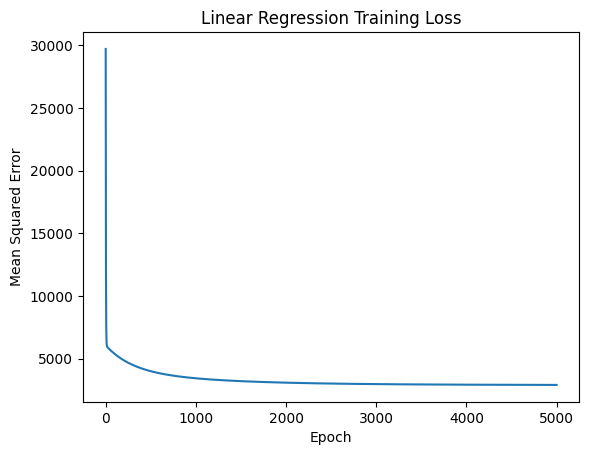

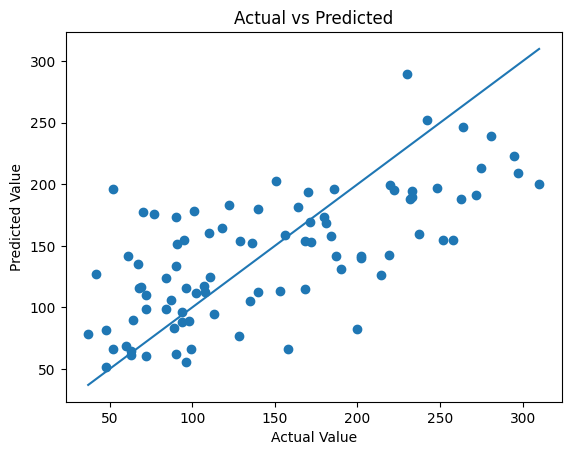

In [12]:
plt.figure()

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Linear Regression Training Loss")

plt.show()

plt.figure()

plt.scatter(y_test, testing_predictions)

minimum = min(y_test.min(), testing_predictions.min())

maximum = max(y_test.max(), testing_predictions.max())

plt.plot([minimum, maximum], [minimum, maximum])

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")

plt.title("Actual vs Predicted")

plt.show()